In [26]:
import awkward as ak
import numpy as np
from coffea import processor
from coffea.nanoevents import NanoEventsFactory as NF, NanoAODSchema
import hist
import matplotlib.pyplot as plt
import mplhep as hep

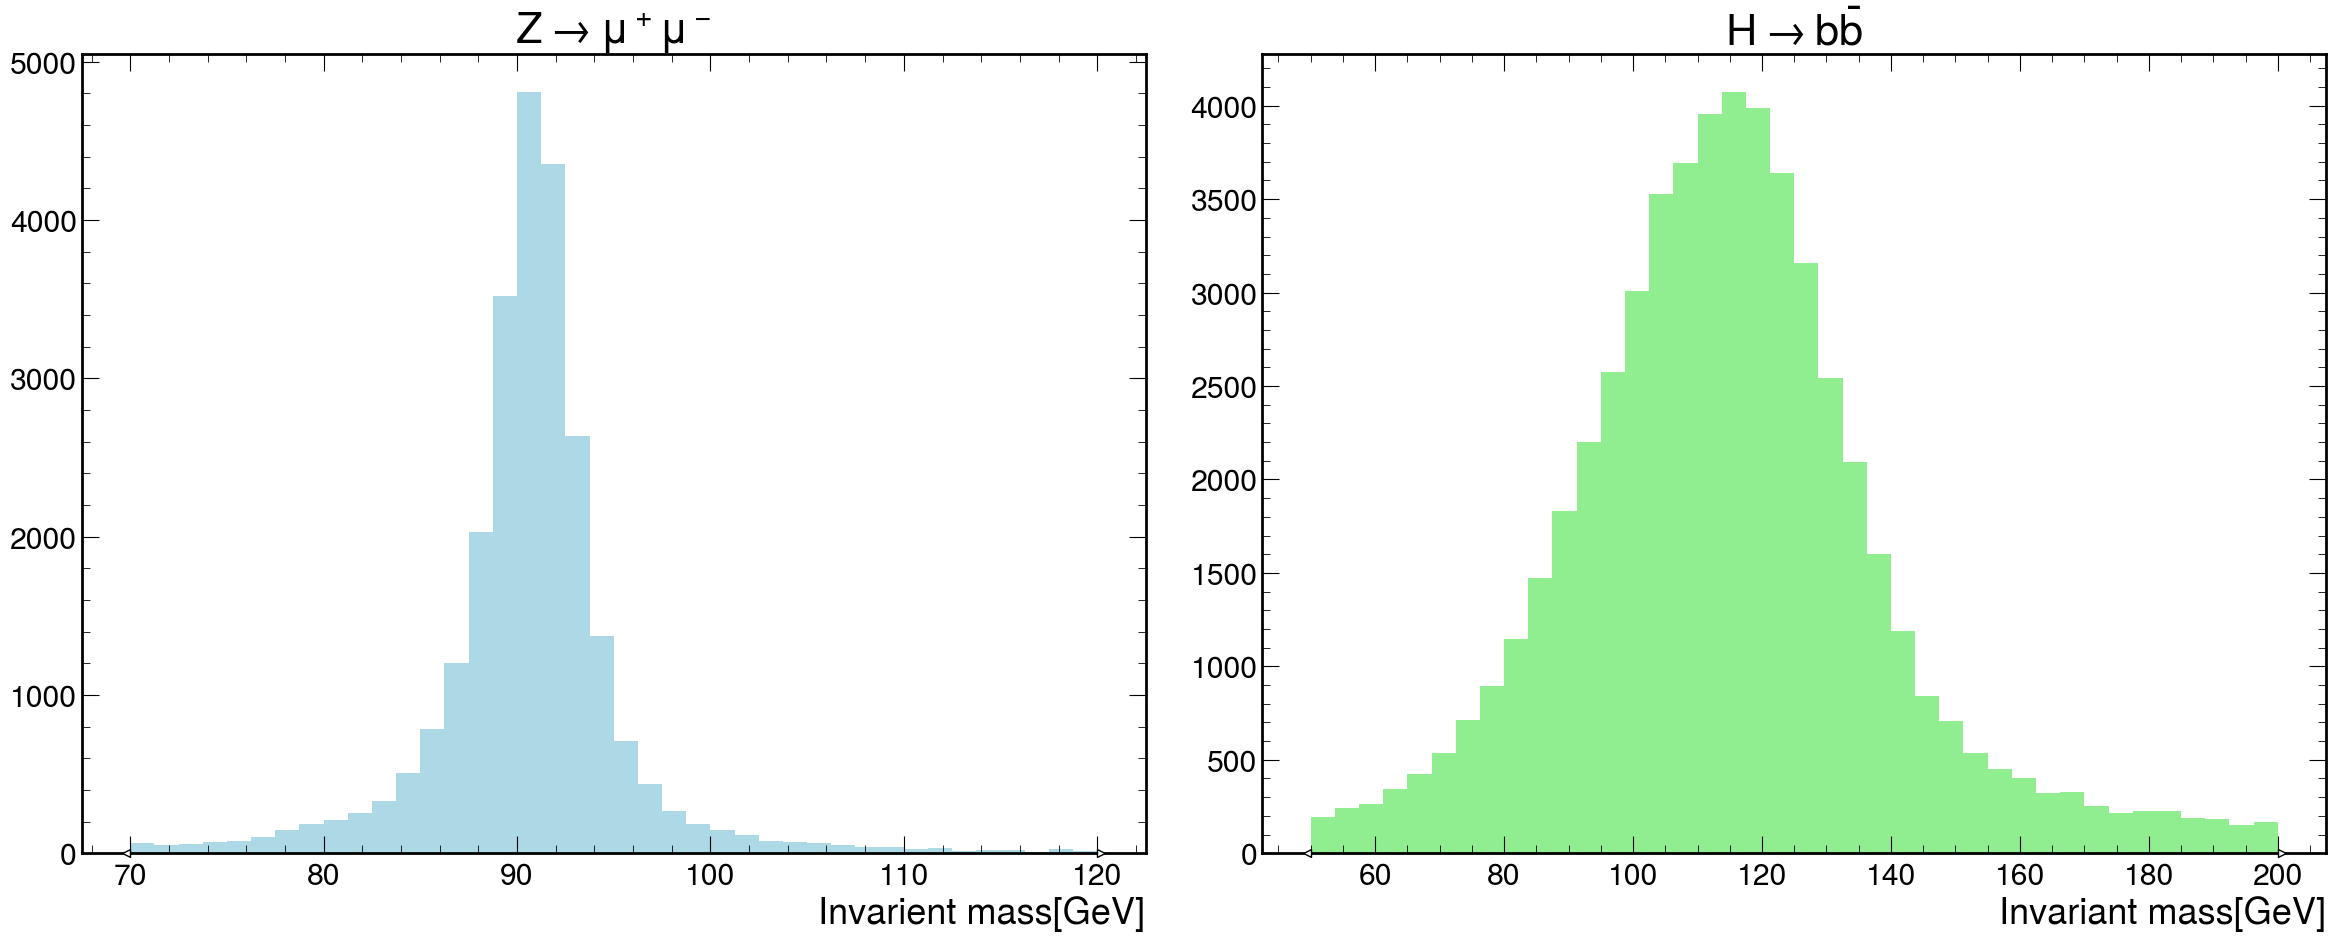

In [85]:
class Zmumu_Hbb(processor.ProcessorABC):

    def __init__(self):
        self.hists={
        "Z_MASS":(hist.Hist.new.Reg(40,70,120,name="mumu",label="Invarient mass[GeV]").Double()),
               "H_MASS":(hist.Hist.new.Reg(40,50,200,name="bb",label="Invariant mass[GeV]").Double())
    }

    def process(self,events):
        #Muon part
        #========================================
        mu=events.Muon

        #Muon cuts--------->
        
        good_muon=(
            (mu.pt>25) & (abs(mu.eta) < 2.4) & mu.mediumId & (mu.pfRelIso04_all<0.15) &
                   (abs(mu.dxy)<0.05) & (abs(mu.dz<0.10))
                  )
       
        
        x1 = ak.argsort(mu.pt, axis=1, ascending=False)
        M = mu[x1]
        M1= M[good_muon]
        mask1= ak.num(M1)>=2
        
        mu1= M1[mask1]
        

        Mu= mu1[:,:2] # only select first two muon per event
        mask2 = (Mu[:,0].charge*Mu[:,1].charge)==-1
        Mu_di = Mu[mask2]

        Di_mu_mass= (Mu_di[:,0]+ Mu_di[:,1]).mass

        self.hists["Z_MASS"].fill(mumu=ak.to_numpy(Di_mu_mass))


        #=====================================================================

        #JET part

        #============================================
        jets= events.Jet
        good_jets= ((jets.pt >30) & (abs(jets.eta)<2.4)
                   )
        sel_jets = jets[good_jets]

        #sort----->
        x2 = ak.argsort(sel_jets.pt, axis=1, ascending=False)
        sjet = sel_jets[x2]

        #btagging----------------->we use btagUParTAK4B
         #============
        bjet= sjet[sjet.btagUParTAK4B > 0.1272 ]  #medium
        
        #Cuts------->
        mask1= ak.num(bjet) >= 2
        Gbjet= bjet[mask1]

        J= Gbjet[:,:2]
        jet1=J[:,0]
        jet2= J[:,1]


        jet_mass = (jet1+jet2).mass #------>mass

        self.hists["H_MASS"].fill(bb=ak.to_numpy(jet_mass))
        return self.hists
        


        def postprocess(self,accumulator):
            return accumulator
#================================================================================

#Analysis
#==============================
if __name__== "__main__":
    events= NF.from_root(r"Z:\Project files\3f1aaaee-242f-44e4-a3d6-56bc2f6fb19b.root:Events",
                         schemaclass=NanoAODSchema).events()

    
    analysis_processor= Zmumu_Hbb()
    output = analysis_processor.process(events)

    #plot------>
    #hep.style.use("CMS")
    fig, ax = plt.subplots(1, 2,figsize=(12,5))


   
    output["Z_MASS"].plot(ax=ax[0], color="lightblue", histtype="fill", linewidth=2)
    ax[0].set_title(r"$Z \rightarrow \mu^+ \mu^-$")
    #hep.cms.label(ax=ax[0])
    
    output["H_MASS"].plot(ax=ax[1],color="lightgreen", histtype="fill", linewidth=2)
    ax[1].set_title(r"$H \rightarrow b\bar{b}$")
    #hep.cms.label(ax=ax[1])

    
    plt.tight_layout(rect=[1,1,3,3])
    plt.show()
#===================================================================================================================================================      